# Задача 1

1. Вектор состояния системы:
$$ x = \begin{bmatrix} \theta_1 \\ \dot{\theta}_1 \\ \theta_2 \\ \dot{\theta}_2 \end{bmatrix} $$
Система полностью определена положениями и скоростями обоих маятников. Растяжение или сжатие пружины может быть выведено через вектор состояния: $\Delta L = - l \sin \theta_1 + l \sin \theta_2$

2. 
$$ E_k = \frac{1}{2} ml^2 (\dot{\theta}_1^2 + \dot{\theta}_2^2) $$
$$ E_p = mgl (2 - \cos \theta_1 - \cos \theta_2) + \frac{1}{2} kl (\sin \theta_2 - \sin \theta_1)^2 $$ 

3. 
$$ L = E_k - E_p = \frac{1}{2} ml^2 (\dot{\theta}_1^2 + \dot{\theta}_2^2) - mgl (2 - \cos \theta_1 - \cos \theta_2) - \frac{1}{2} kl (\sin \theta_2 - \sin \theta_1)^2 $$

Применим Эйлера-Лагранжа к обоим маятникам. Для первого маятника:
$$ \frac{d}{dt} \frac{\partial L}{\partial \dot{\theta}_1} - \frac{\partial L}{\partial \theta_1} = 0 \iff $$
$$ ml^2 \ddot{\theta}_1 + mgl \sin \theta_1 - kl (\sin \theta_2 - \sin \theta_1) \cos \theta_1 = 0 $$
И для второго:
$$ \frac{d}{dt} \frac{\partial L}{\partial \dot{\theta}_2} - \frac{\partial L}{\partial \theta_2} = 0 \iff $$
$$ ml^2 \ddot{\theta}_2 + mgl \sin \theta_2 + kl (\sin \theta_2 - \sin \theta_1) \cos \theta_2 = 0 $$

Откуда получаем выражения для ускорений:
$$ \ddot{\theta}_1 = \frac{k (\sin \theta_2 - \sin \theta_1) \cos \theta_1}{ml} - \frac{g \sin \theta_1}{l} $$
$$ \ddot{\theta}_2 = -\frac{k (\sin \theta_2 - \sin \theta_1) \cos \theta_2}{ml} - \frac{g \sin \theta_2}{l} $$

4. В окрестности нулевых углов система линеаризуется, если приблизить $\sin \theta_i \approx \theta_i, \cos \theta_i \approx 1$:
$$ \dot{x} = A x \iff $$
$$ \begin{bmatrix} \dot{\theta}_1 \\ \ddot{\theta}_1 \\ \dot{\theta}_2 \\ \ddot{\theta}_2 \end{bmatrix} = \begin{bmatrix} 0 & 1 & 0 & 0 \\ -(\frac{k}{ml} + \frac{g}{l}) & 0 & \frac{k}{ml} & 0 \\ 0 & 0 & 0 & 1 \\ \frac{k}{ml} & 0 & -(\frac{k}{ml} + \frac{g}{l}) & 0 \end{bmatrix} \begin{bmatrix} \theta_1 \\ \dot{\theta}_1 \\ \theta_2 \\ \dot{\theta}_2 \end{bmatrix} $$

# Задача 2

In [1]:
from typing import Optional, List, Tuple, Callable, Dict, Iterable
import numpy as np
import cv2


class DoublePendulumSimulator:
    def __init__(
        self,
        m: float = 1.0,
        k: float = 2.0,
        g: float = 9.81,
        l: float = 10.0,
        dt: float = 0.1,
        linearized: bool = False,
    ):
        self.m = m
        self.k = k
        self.g = g
        self.l = l
        self.dt = dt
        self.state = np.zeros(4)
        self.t = 0
        self.linearized = linearized

        self.A = np.array(
            [
                [0, 1, 0, 0],
                [-(self.k / (self.m * self.l)) - (self.g / self.l), 0, self.k / (self.m * self.l), 0],
                [0, 0, 0, 1],
                [self.k / (self.m * self.l), 0, -(self.k / (self.m * self.l)) - (self.g / self.l), 0],
            ]
        )

    def _get_x_dot(self, x: np.ndarray) -> np.ndarray:
        if self.linearized:
            return self.A @ x
        else:
            theta_1, theta_1_dot, theta_2, theta_2_dot = x
            theta_1_ddot = (self.k * (np.sin(theta_2) - np.sin(theta_1)) * np.cos(theta_1)) / (self.m * self.l) - (
                self.g * np.sin(theta_1)
            ) / self.l
            theta_2_ddot = (-self.k * (np.sin(theta_2) - np.sin(theta_1)) * np.cos(theta_2)) / (self.m * self.l) - (
                self.g * np.sin(theta_2)
            ) / self.l
            return np.array([theta_1_dot, theta_1_ddot, theta_2_dot, theta_2_ddot])

    def reset(self, state: Optional[np.ndarray] = None):
        if state is None:
            self.state = np.zeros(4)
        else:
            self.state = state
        self.t = 0

    def step(self):
        self.state += self._get_x_dot(self.state) * self.dt
        self.t += self.dt

    def render(self):
        canvas = np.full(shape=(1000, 1000, 3), fill_value=255, dtype=np.uint8)
        scale = 400 / self.l

        cx1, cy1, cx2, cy2 = 300, 120, 700, 120
        Lpx = self.l * scale

        theta_1, _, theta_2, theta_2_dot = self.state

        p1 = (int(cx1 + Lpx * np.sin(theta_1)), int(cy1 + Lpx * np.cos(theta_1)))
        p2 = (int(cx2 + Lpx * np.sin(theta_2)), int(cy2 + Lpx * np.cos(theta_2)))
        pivot1 = (cx1, cy1)
        pivot2 = (cx2, cy2)

        cv2.line(canvas, pivot1, p1, (0, 0, 0), 3, cv2.LINE_AA)
        cv2.line(canvas, pivot2, p2, (0, 0, 0), 3, cv2.LINE_AA)

        def draw_spring(img, a, b, color=(120, 120, 120), thickness=2, coils=14, amplitude=12):
            ax, ay = a
            bx, by = b
            vx, vy = bx - ax, by - ay
            length = float(np.hypot(vx, vy)) + 1e-9
            ux, uy = vx / length, vy / length
            nx, ny = -uy, ux

            pts = [(int(ax), int(ay))]
            for i in range(1, coils):
                t = i / coils
                sign = 1 if i % 2 else -1
                px = ax + vx * t + nx * (sign * amplitude)
                py = ay + vy * t + ny * (sign * amplitude)
                pts.append((int(round(px)), int(round(py))))
            pts.append((int(bx), int(by)))

            cv2.polylines(img, [np.array(pts, dtype=np.int32)], False, color, thickness, cv2.LINE_AA)

        draw_spring(canvas, p1, p2)

        cv2.circle(canvas, p1, 14, (40, 40, 220), -1, cv2.LINE_AA)
        cv2.circle(canvas, p2, 14, (220, 40, 40), -1, cv2.LINE_AA)

        cv2.circle(canvas, pivot1, 6, (0, 0, 0), -1, cv2.LINE_AA)
        cv2.circle(canvas, pivot2, 6, (0, 0, 0), -1, cv2.LINE_AA)

        cv2.putText(
            canvas,
            f"t={self.t:.2f}s  theta1={theta_1:.2f} rad  theta2={theta_2:.2f} rad",
            (28, 44),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 0),
            2,
            cv2.LINE_AA,
        )

        return canvas


def save_video(frames: List[np.ndarray], filename: str, fps: int):
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(filename, fourcc, fps, (frames[0].shape[1], frames[0].shape[0]))
    for frame in frames:
        out.write(frame)
    out.release()


dt = 0.01
fps = int(1 / dt)
sim = DoublePendulumSimulator(dt=dt)
sim.reset(np.array([0, 0, -np.pi / 24, 0]))

frames = []
for _ in range(1000):
    frames.append(sim.render())
    sim.step()

save_video(frames, "output.mp4", fps=fps)

# Задача 3

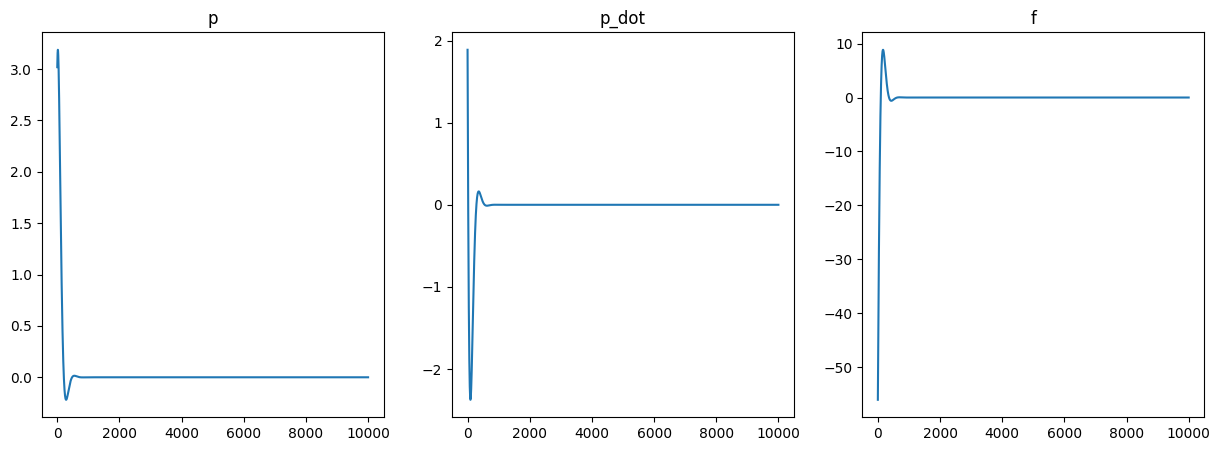

In [2]:
from matplotlib import pyplot as plt

def simulate(
    m: float = 5.0,
    p: float = 3.0,
    p_dot: float = 2.0,
    dt: float = 0.01,
    num_iter: int = 10000,
    kp: float = 12,
    kd: float = 10,
) -> Tuple[List[float], List[float], List[float]]:
    ps, pds, fs = [], [], []

    for _ in range(num_iter):
        f = -kp * p - kd * p_dot
        p_ddot = f / m
        p_dot += p_ddot * dt
        p += p_dot * dt
        ps.append(p)
        pds.append(p_dot)
        fs.append(f)

    return ps, pds, fs

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

dt = 0.01
ps, pds, fs = simulate(dt=dt)

axes[0].plot(ps)
axes[0].set_title("p")
axes[1].plot(pds)
axes[1].set_title("p_dot")
axes[2].plot(fs)
axes[2].set_title("f")

plt.show()

In [3]:
def score_fn(p: List[float], p_dot: List[float], f: List[float], dt: float) -> float:
    return (np.square(p) * 3 + np.square(p_dot) * 5 + np.square(f) * 8).sum() * dt

score = score_fn(ps, pds, fs, dt=dt)
print(f"Score: {score}")

Score: 6846.457069317332


# Задача 4

In [4]:
from itertools import product

def optimize(fn: Callable, param_ranges: Dict[str, Iterable[float]]):
    best_value = float("inf")
    best_params = None
    keys, values = zip(*param_ranges.items())

    for params in product(*values):
        kwargs = {k: p for k, p in zip(keys, params)}
        new_value = fn(**kwargs)
        if new_value < best_value:
            best_params = kwargs
            best_value = new_value
    
    return best_params, best_value

def objective(kp: float, kd: float):
    ps, pds, fs = simulate(kp=kp, kd=kd, dt=0.01)
    return score_fn(ps, pds, fs, dt=0.01)

kps = np.linspace(0, 30, 50)
kds = np.linspace(0, 30, 50)

best_params, best_value = optimize(objective, {"kp": kps, "kd": kds})

print(f"Best cost: {best_value:.3f} achieved with params: {best_params}")

Best cost: 822.885 achieved with params: {'kp': np.float64(0.6122448979591837), 'kd': np.float64(2.4489795918367347)}
